In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Scorecard Model

Loads the train/validation splits produced in `home_credit.ipynb`, buckets the
numerical columns with `TreeBucketer`, and builds a logistic regression
scorecard on top of them.

In [23]:
DATA_DIR = Path("home_credit") / "processed"

train_df = pd.read_csv(DATA_DIR / "train_df.csv")
val_df = pd.read_csv(DATA_DIR / "val_df.csv")

train_df.shape, val_df.shape

((246008, 16), (61503, 16))

## Decision-Tree Bucketing

Bucket every numerical column using `TreeBucketer` (`tree_bucketer.py`) instead
of plain quantile bucketing - each column's bucket edges come from a decision
tree fit against `TARGET` on that column alone (`min_samples_leaf=0.05`), so
the boundaries fall wherever the data actually separates goods from bads
rather than at arbitrary equal-frequency points. Edges are learned from the
training data only and then applied to validation, same no-leakage rule as
before.

In [24]:
from loan_column_analysis import infer_semantic_type
from tree_bucketer import TreeBucketer

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

# Only bucket genuinely numerical columns - identifiers, TARGET, and small
# integer-coded/binary columns pass through unbucketed, same convention used
# for the quantile bucketing in home_credit.ipynb.
numerical_cols = [
    col for col in train_df.columns
    if col not in (ID_COL, TARGET_COL)
    and infer_semantic_type(train_df[col]) in ("numeric (continuous)", "numeric (discrete)")
]

bucketer = TreeBucketer(min_samples_leaf=0.05)
bucketer.fit(train_df[numerical_cols], train_df[TARGET_COL])

train_bucketed = train_df.copy()
val_bucketed = val_df.copy()
train_bucketed[numerical_cols] = bucketer.transform(train_df[numerical_cols])
val_bucketed[numerical_cols] = bucketer.transform(val_df[numerical_cols])

val_bucketed[numerical_cols].head()

train_bucketed = train_bucketed.drop(labels=["AVG_OWED_30D"], axis=1)
val_bucketed = val_bucketed.drop(labels=["AVG_OWED_30D"], axis=1)

## Weight-of-Evidence Encoding + Logistic Regression

A scorecard's points formula (Siddiqi, *Credit Risk Scorecards*) is built for a
logistic regression fit on **Weight-of-Evidence (WOE)** encoded features, not
one-hot encoded ones - one coefficient per feature, with each bucket's WOE
value carrying that bucket's own log-odds information. This is what lets the
points-per-bucket formula fall out cleanly later.

For feature $i$, bucket $b$:

$$	ext{WOE}_{i,b} = \left(\frac{\%\,	ext{good}_b}{\%\,	ext{bad}_b}
ight)$$

where *good* = `TARGET == 0` and *bad* = `TARGET == 1`, and the percentages are
each bucket's share of all goods / all bads (not of the bucket itself). WOE
bins are learned from the training data only and then applied to validation,
same as the quantile bucket edges in `home_credit.ipynb`.

In [25]:
TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

from scorecard_transformers import PresenceBinarizer, ManualCategoryGrouper, WOEEncoder

feature_cols = [c for c in train_bucketed.columns if c not in (TARGET_COL, ID_COL)]

X_train = train_bucketed[feature_cols]
y_train = train_bucketed[TARGET_COL]
X_val = val_bucketed[feature_cols]
y_val = val_bucketed[TARGET_COL]

# NUM_LATE_30D/NUM_DPD_30 are counts of late-payment/DPD-30 events - collapse
# to a simple 0 (none) / 1 (at least one) flag rather than keeping every
# individual count as its own bucket. Stateless (fit() is a no-op), so the
# same fitted instance is reused for both train and val.
BINARIZE_PRESENCE_COLS = ["NUM_LATE_30D", "NUM_DPD_30"]
binarizer = PresenceBinarizer(cols=BINARIZE_PRESENCE_COLS).fit(X_train)
X_train = binarizer.transform(X_train)
X_val = binarizer.transform(X_val)

# Manually specified groupings for these 4 columns, with descriptive group
# labels chosen by hand rather than an automatic rare-category merge.
MANUAL_GROUP_MAPS: dict[str, dict] = {
    "CODE_GENDER": {"F": "F", "M": "M", "XNA": "M"},
    "NAME_TYPE_SUITE": {
        "Children": "Family",
        "Family": "Family",
        "Spouse, partner": "Family",
        "Unaccompanied": "Unaccompanied and Others",
        "Other_A": "Unaccompanied and Others",
        "Other_B": "Unaccompanied and Others",
        "Group of people": "Unaccompanied and Others",
        "Missing": "Unaccompanied and Others",
    },
    "NAME_INCOME_TYPE": {
        "Working": "Working",
        "Unemployed": "Working",
        "Maternity leave": "Working",
        "Commercial associate": "Commercial associate",
        "Businessman": "Commercial associate",
        "Pensioner": "Pensioner",
        "Student": "Pensioner",
        "State servant": "State servant",
    },
}

# CNT_CHILDREN's own bucketing (every value above 2 -> "2+") is handled
# inside ManualCategoryGrouper itself, not through MANUAL_GROUP_MAPS - see
# scorecard_transformers.py. Also stateless.
grouper = ManualCategoryGrouper(group_maps=MANUAL_GROUP_MAPS).fit(X_train)
X_train_grouped = grouper.transform(X_train)
X_val_grouped = grouper.transform(X_val)

# --- learn a WOE map per feature from the training data only, then apply
# it to both train and val - no rare-category merge (WOEEncoder is pure WOE
# encoding; grouping is handled entirely by the two steps above). ---
woe_encoder = WOEEncoder().fit(X_train_grouped, y_train)
woe_maps = woe_encoder.woe_maps_

X_train_woe = woe_encoder.transform(X_train_grouped)
X_val_woe = woe_encoder.transform(X_val_grouped)

### WOE Before Manual Grouping

For comparison against the grouped version below: WOE computed directly on
`X_train`/`X_val`, before the manual category groupings (`MANUAL_GROUP_MAPS`)
were applied.

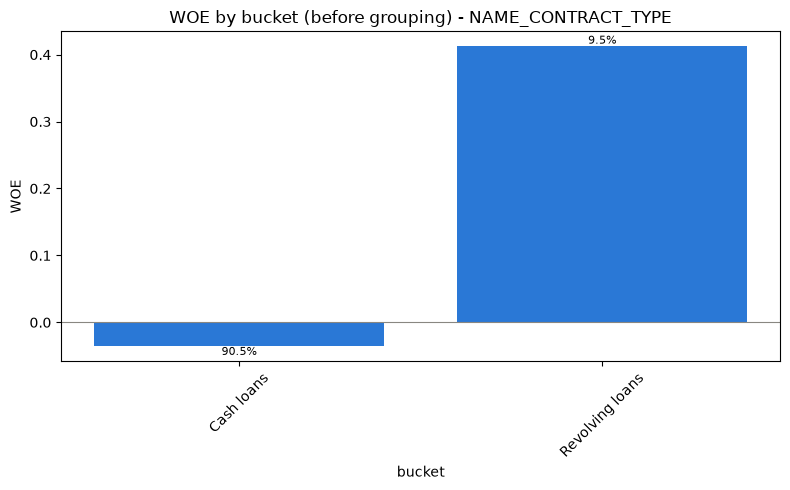

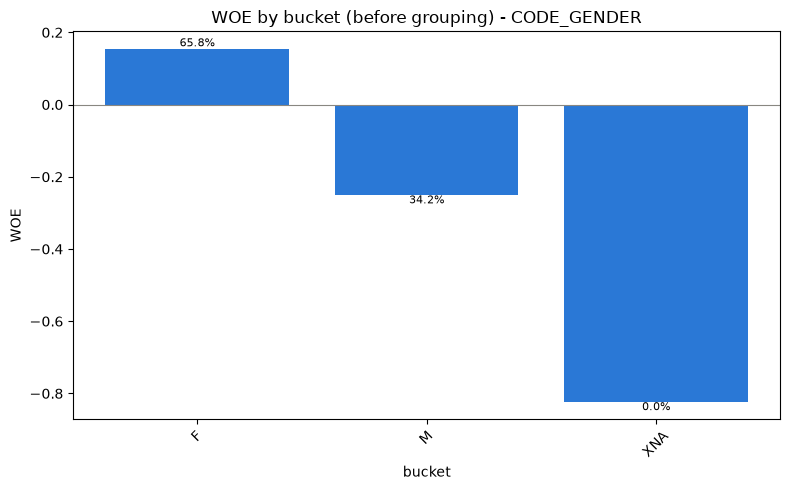

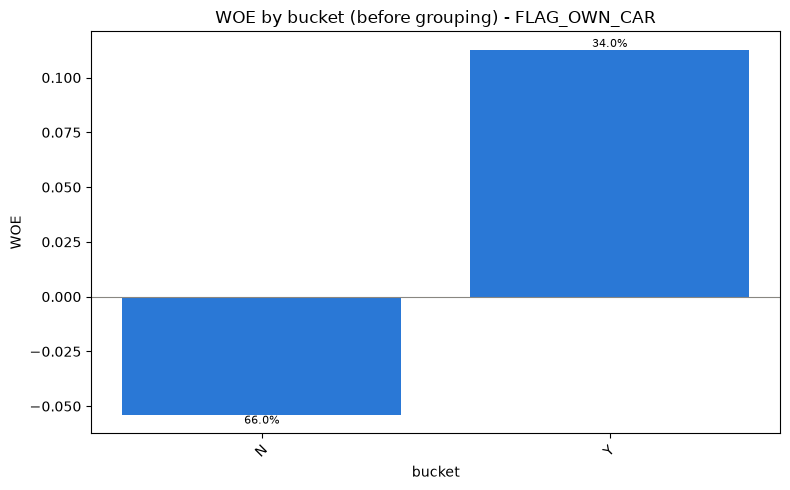

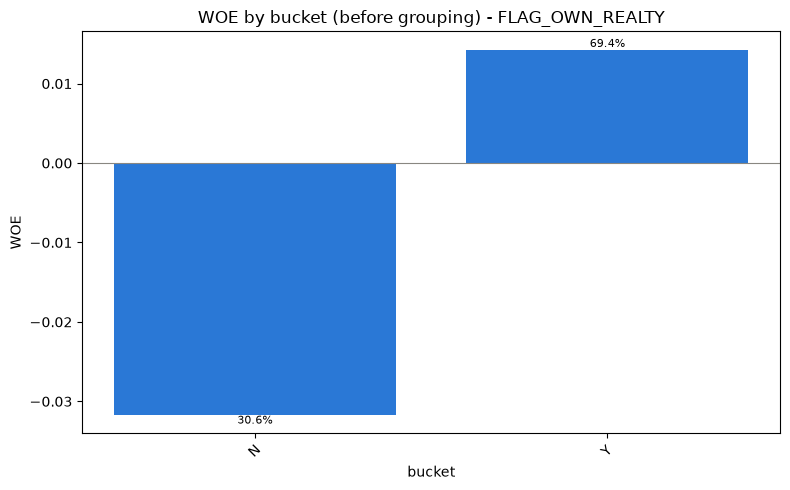

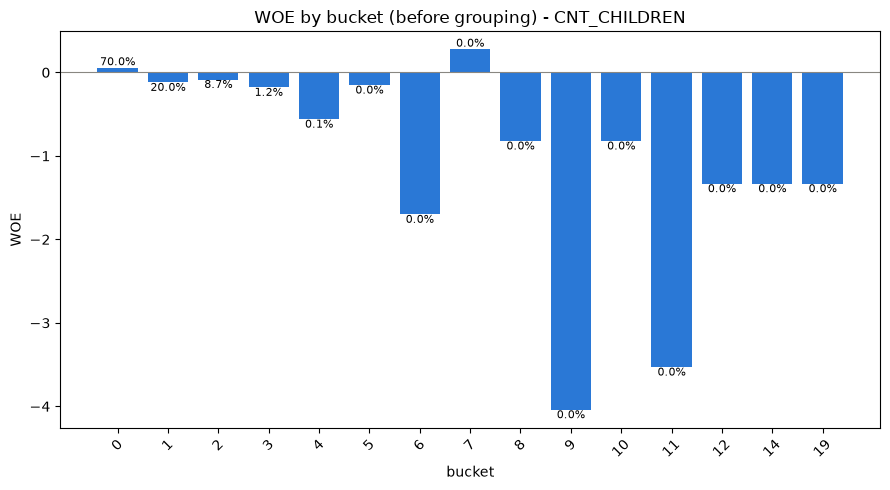

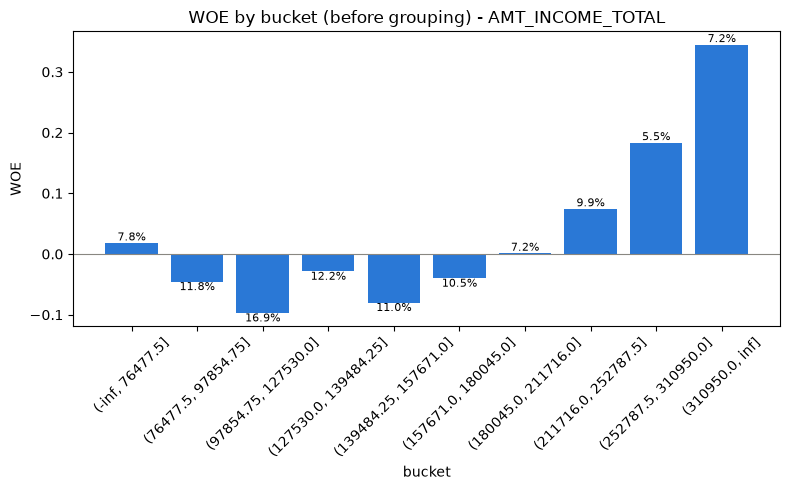

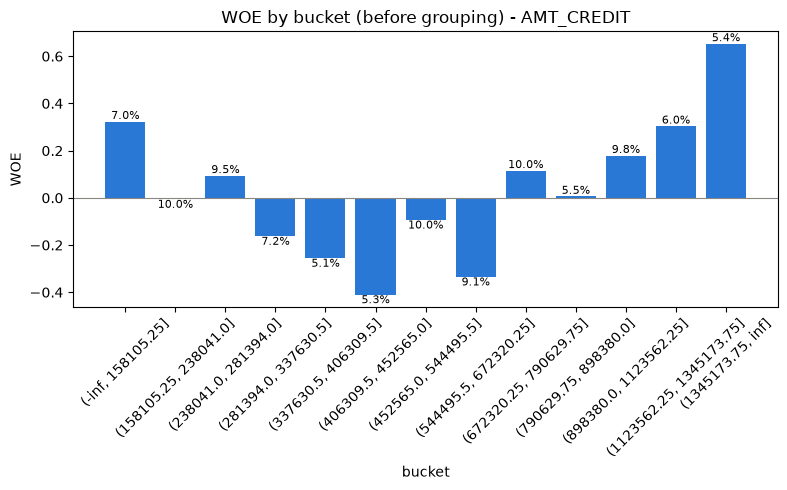

TypeError: 'value' must be an instance of str or bytes, not a float

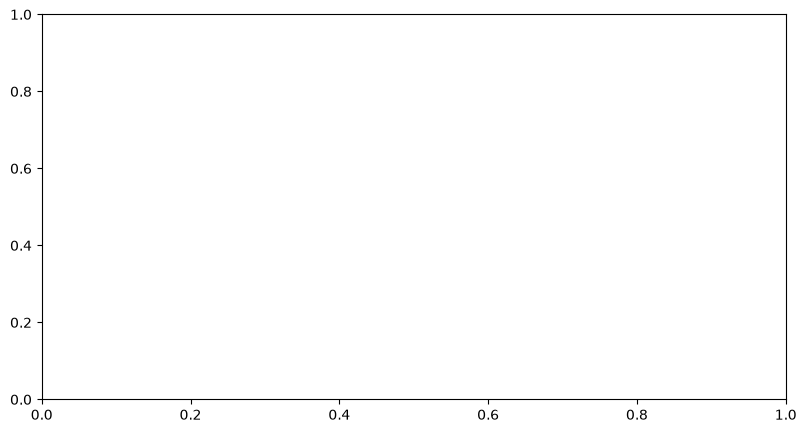

In [26]:
from palette import SEQUENTIAL_BLUE, INK_MUTED

# --- WOE per feature computed on the raw (ungrouped) buckets, for comparison
# against the rare-category-grouped version further down. ---
woe_maps_ungrouped = WOEEncoder().fit(X_train, y_train).woe_maps_

for col in feature_cols:
    counts = X_train[col].value_counts(dropna=False)
    pct_of_data = 100 * counts / len(X_train)

    woe_table = pd.concat(
        [pct_of_data.rename("pct_of_data"), woe_maps_ungrouped[col].rename("woe")], axis=1,
    ).sort_index()

    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(woe_table)), 5))
    bars = ax.bar(woe_table.index.astype(str), woe_table["woe"], color=SEQUENTIAL_BLUE)

    for bar, pct in zip(bars, woe_table["pct_of_data"]):
        y = bar.get_height()
        va = "bottom" if y >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{pct:.1f}%", ha="center", va=va, fontsize=8)

    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_title(f"WOE by bucket (before grouping) - {col}")
    ax.set_xlabel("bucket")
    ax.set_ylabel("WOE")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

### WOE Map Inspection

For every feature, list each bucket's share of the training data (not just
share of goods/bads - the plain frequency of that bucket overall) alongside
its WOE value, so a bucket's influence on the score can be weighed against how
common it actually is.

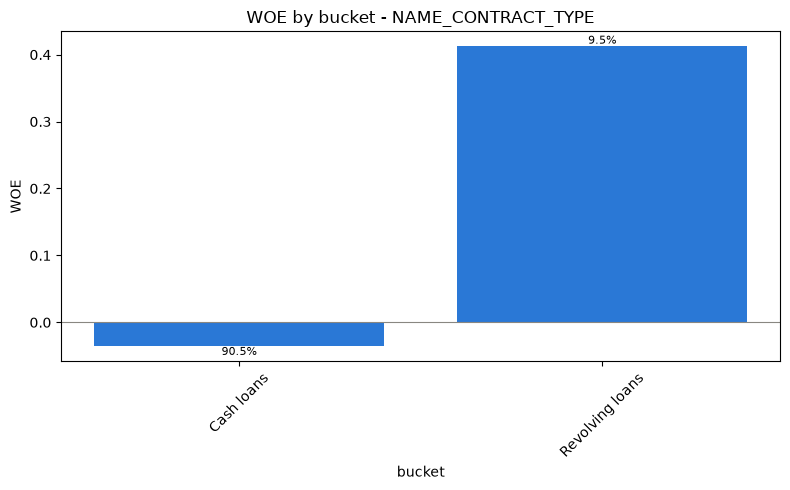

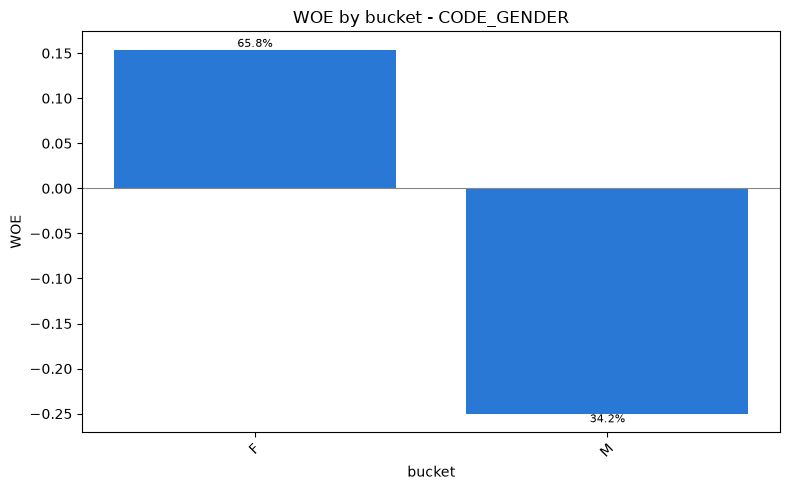

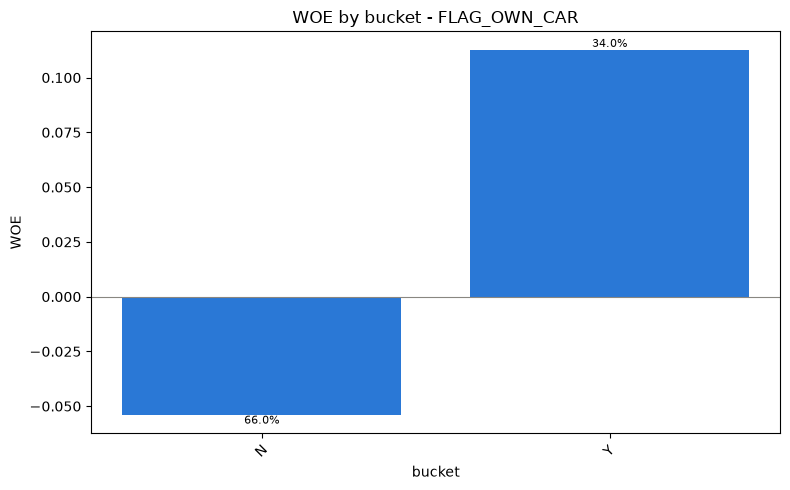

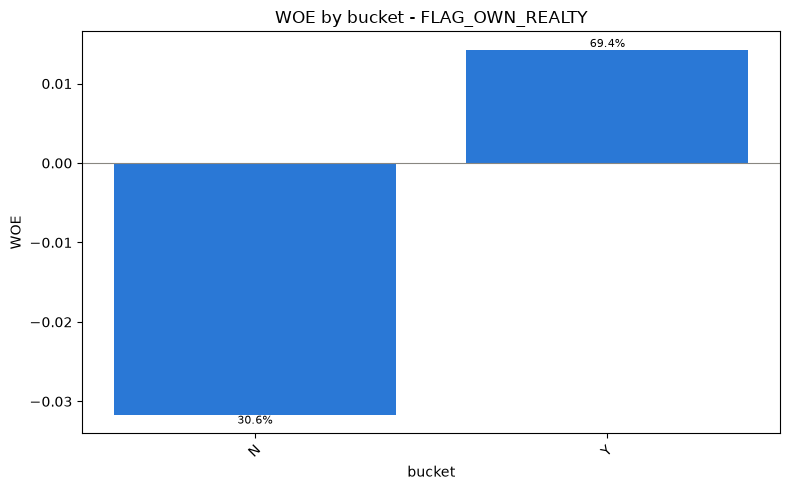

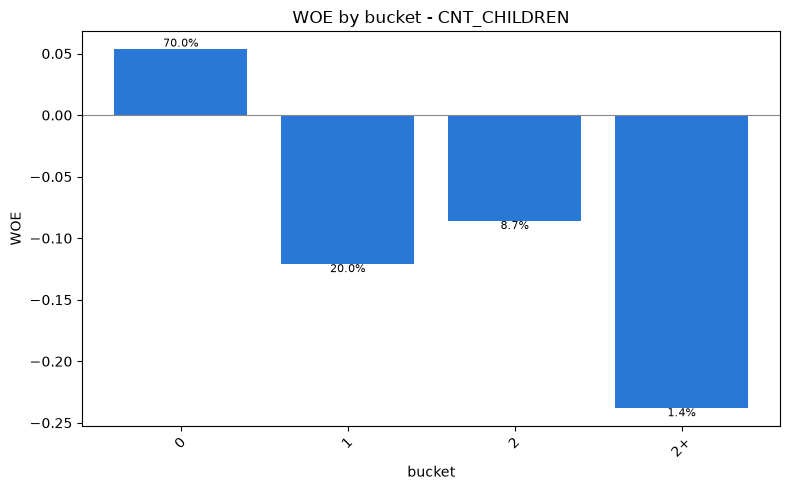

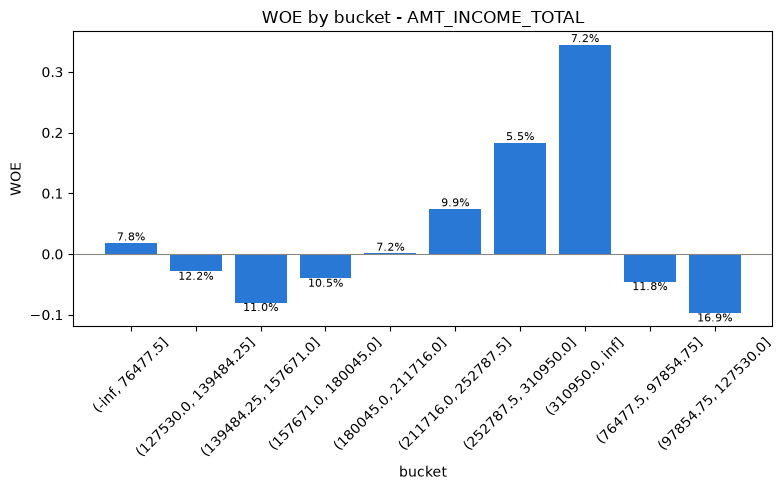

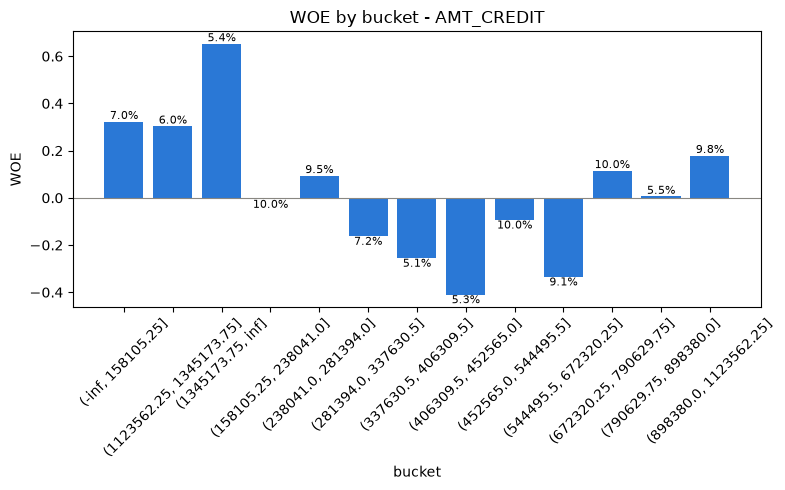

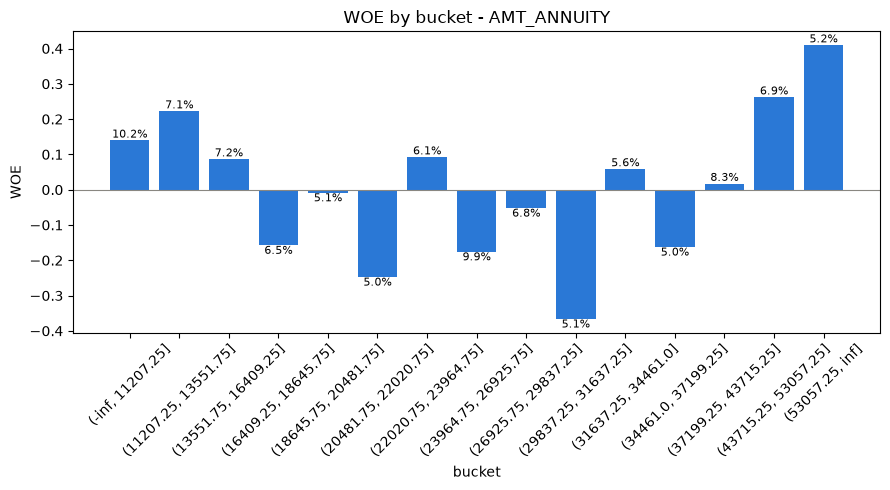

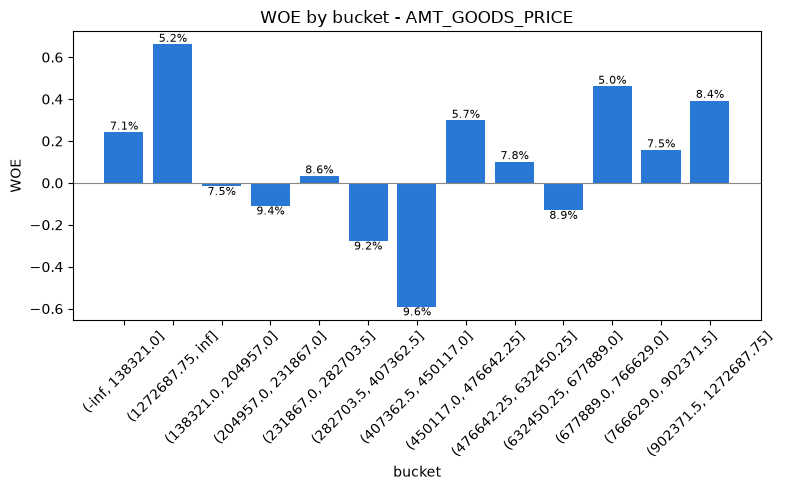

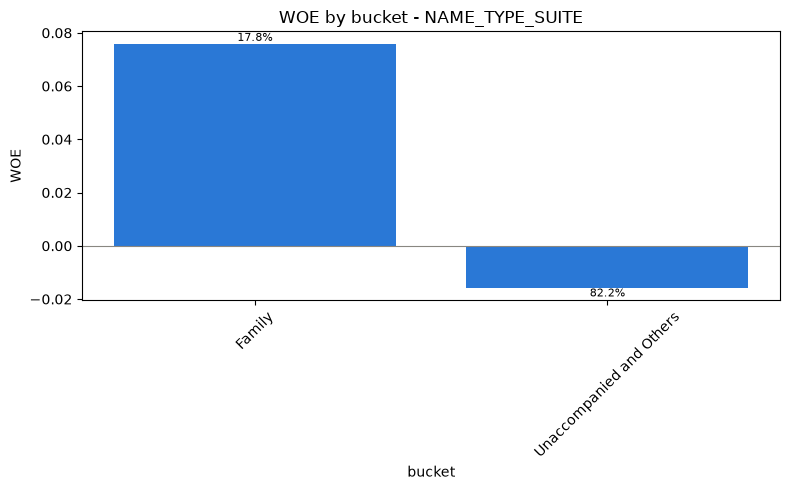

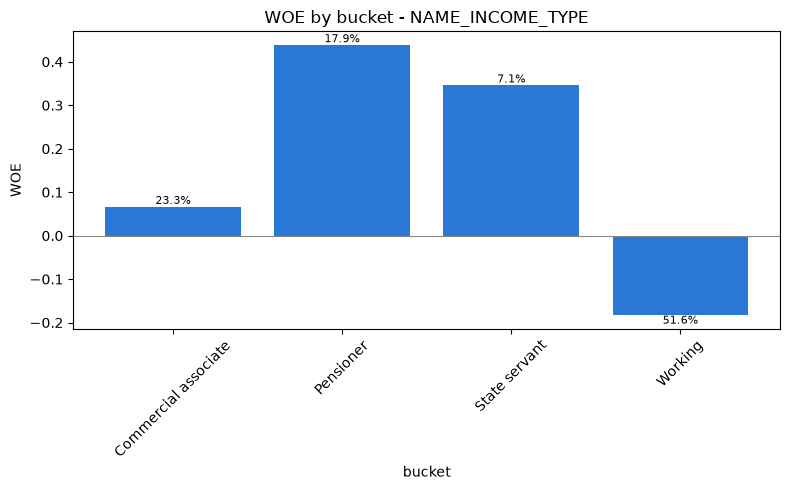

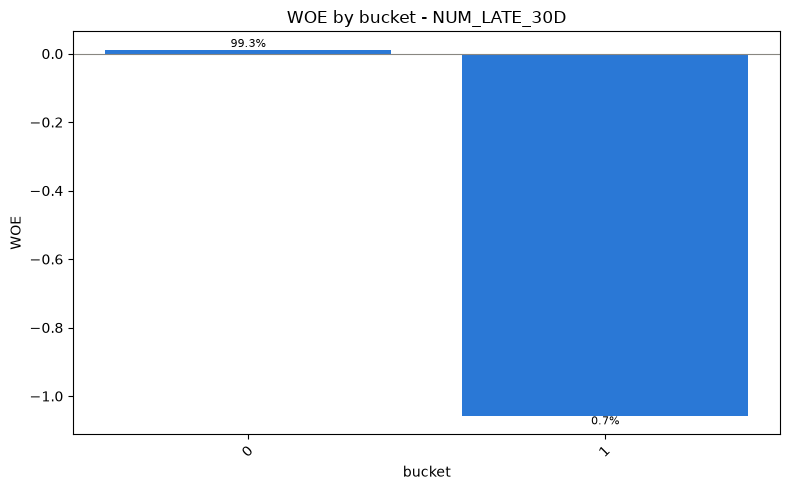

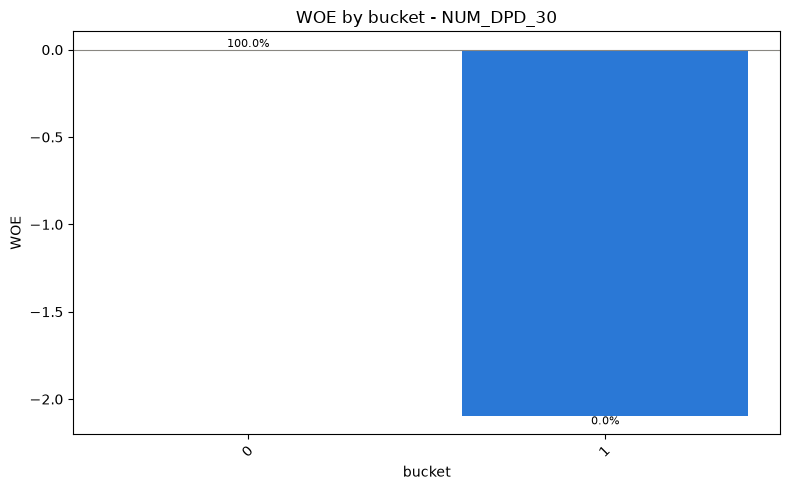

In [ ]:
from palette import SEQUENTIAL_BLUE, INK_MUTED

for col in feature_cols:
    # X_train_grouped, not X_train - the rare-category grouping happened
    # before woe_maps was computed, so the buckets shown here need to match
    # what woe_maps actually holds keys for.
    counts = X_train_grouped[col].value_counts(dropna=False)
    pct_of_data = 100 * counts / len(X_train_grouped)

    woe_table = pd.concat(
        [pct_of_data.rename("pct_of_data"), woe_maps[col].rename("woe")], axis=1,
    ).sort_index()

    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(woe_table)), 5))
    bars = ax.bar(woe_table.index.astype(str), woe_table["woe"], color=SEQUENTIAL_BLUE)

    # Annotate each bar with its share of the training data, so a bucket's
    # WOE can be weighed against how common it actually is.
    for bar, pct in zip(bars, woe_table["pct_of_data"]):
        y = bar.get_height()
        va = "bottom" if y >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{pct:.1f}%", ha="center", va=va, fontsize=8)

    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_title(f"WOE by bucket - {col}")
    ax.set_xlabel("bucket")
    ax.set_ylabel("WOE")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:


logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_woe, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Evaluation

              precision    recall  f1-score   support

           0       0.93      0.95      0.94     56538
           1       0.19      0.13      0.15      4965

    accuracy                           0.88     61503
   macro avg       0.56      0.54      0.55     61503
weighted avg       0.87      0.88      0.87     61503



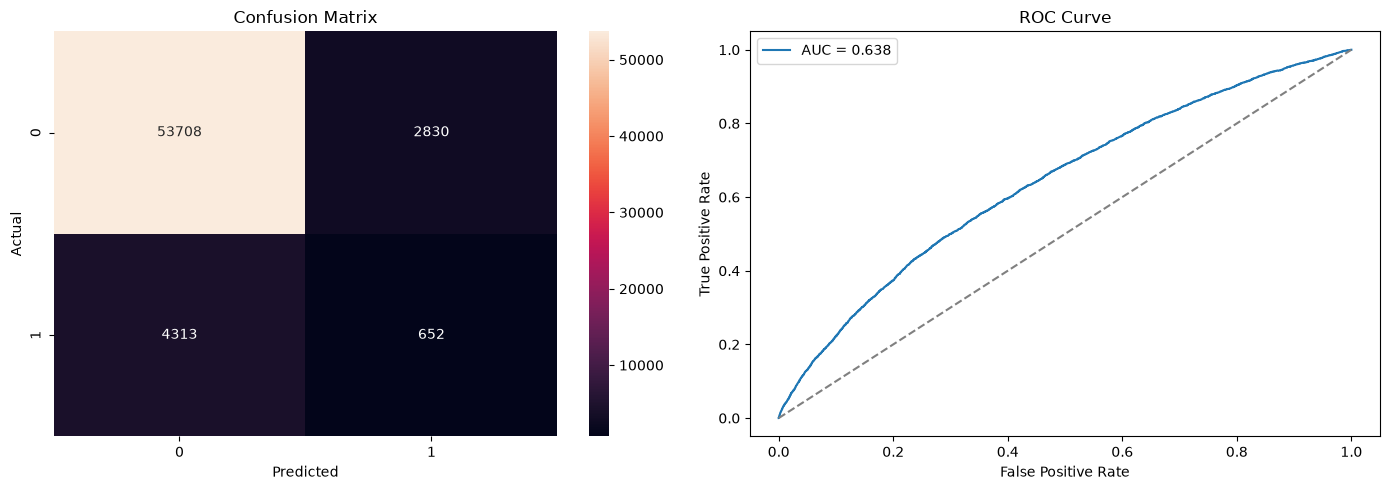

In [ ]:
threshold = 0.15

positive_class_idx = list(logreg.classes_).index(1)
y_score = logreg.predict_proba(X_val_woe)[:, positive_class_idx]
y_pred = (y_score > threshold) * 1

print(classification_report(y_val, y_pred))

fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt="d", ax=ax_cm)
ax_cm.set_title("Confusion Matrix")
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_val, y_score)
auc = roc_auc_score(y_val, y_score)
ax_roc.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax_roc.set_title("ROC Curve")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

plt.tight_layout()
plt.show()

## Coefficient to Score Conversion (Siddiqi)

Standard points-to-double-odds (PDO) scaling from Siddiqi's *Credit Risk
Scorecards*:

$$	ext{Score} = 	ext{Offset} + 	ext{Factor} 	imes \ln(	ext{odds})$$

Solving for Factor/Offset from a chosen base score/odds and a points-to-double-
the-odds value:

$$	ext{Factor} = rac{	ext{PDO}}{\ln(2)} \qquad
	ext{Offset} = 	ext{Base\_Score} - 	ext{Factor} 	imes \ln(	ext{Base\_Odds})$$

Per-bucket points then fall out of the fitted WOE logistic regression's
coefficients ($eta_i$ per feature, $lpha$ intercept, $n$ = number of
features), spreading the intercept evenly across features so the points sum to
the full score:

$$	ext{points}_{i,b} = -\left(eta_i 	imes 	ext{WOE}_{i,b} + rac{lpha}{n}
ight) 	imes 	ext{Factor}$$

`BASE_SCORE`/`BASE_ODDS`/`PDO` below use Siddiqi's own worked-example values
(600 points at 50:1 odds, doubling every 20 points) - standard textbook
defaults, adjust to whatever convention the business wants.

In [ ]:
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

n_features = len(feature_cols)
intercept = logreg.intercept_[0]
coefs = pd.Series(logreg.coef_[0], index=feature_cols)


def build_scorecard(woe_maps: dict, coefs: pd.Series, intercept: float, n_features: int, factor: float, offset: float) -> pd.DataFrame:
    """Per-bucket points table: one row per (feature, bucket) pair.

    points_i,b = -(beta_i * WOE_i,b + alpha / n_features) * factor
    """
    rows = []
    for feature, woe_map in woe_maps.items():
        beta = coefs[feature]
        for bucket, woe in woe_map.items():
            points = -(beta * woe + intercept / n_features) * factor
            rows.append({"feature": feature, "bucket": str(bucket), "woe": woe, "points": points})
    return pd.DataFrame(rows)


scorecard_table = build_scorecard(woe_maps, coefs, intercept, n_features, FACTOR, OFFSET)
scorecard_table.sort_values(["points"]).reset_index(drop=True)

,feature,bucket,woe,points
0,NUM_LATE_30D,1,-1.057813,-21.432665
1,AMT_GOODS_PRICE,"(407362.5, 450117.0]",-0.591661,-8.192530
2,NUM_DPD_30,1,-2.095964,-7.226718
3,CODE_GENDER,M,-0.250218,-2.790865
4,AMT_GOODS_PRICE,"(282703.5, 407362.5]",-0.277676,-0.981386
...,...,...,...,...
68,AMT_GOODS_PRICE,"(902371.5, 1272687.75]",0.393070,14.423347
69,NAME_INCOME_TYPE,Pensioner,0.439050,15.889300
70,AMT_GOODS_PRICE,"(677889.0, 766629.0]",0.460538,15.972838
71,NAME_CONTRACT_TYPE,Revolving loans,0.412397,18.022760


## Analysis of Engineered Features

In [ ]:
scorecard_table[scorecard_table.feature == "AMT_ANNUITY"]

,feature,bucket,woe,points
35,AMT_ANNUITY,"(-inf, 11207.25]",0.139981,6.630819
36,AMT_ANNUITY,"(11207.25, 13551.75]",0.222814,7.361592
37,AMT_ANNUITY,"(13551.75, 16409.25]",0.086869,6.162256
38,AMT_ANNUITY,"(16409.25, 18645.75]",-0.157924,4.002633
39,AMT_ANNUITY,"(18645.75, 20481.75]",-0.008975,5.316698
40,AMT_ANNUITY,"(20481.75, 22020.75]",-0.247929,3.208596
41,AMT_ANNUITY,"(22020.75, 23964.75]",0.092495,6.211888
42,AMT_ANNUITY,"(23964.75, 26925.75]",-0.176204,3.841364
43,AMT_ANNUITY,"(26925.75, 29837.25]",-0.052533,4.932422
44,AMT_ANNUITY,"(29837.25, 31637.25]",-0.366602,2.161634


## Scoring a Row

Score a row by looking up each feature's bucket in `scorecard_table` and
summing the points, since the per-bucket points already absorb the intercept's
share (`alpha / n_features`) - no separate offset addition needed on top.

In [ ]:
points_lookup = scorecard_table.set_index(["feature", "bucket"])["points"]


def score_row(row: pd.Series, feature_cols: list[str]) -> float:
    """Sum a row's per-bucket points, feature by feature.

    A bucket unseen in training (including real missing values, which
    stringify to "nan" and were never a key here) has no learned points -
    contributes 0, the same "no information" fallback apply_woe() uses during
    regression, rather than raising or propagating NaN through the sum.
    """
    return sum(points_lookup.get((col, str(row[col])), 0.0) for col in feature_cols)


val_scores = val_bucketed[feature_cols].apply(lambda row: score_row(row, feature_cols), axis=1)
val_scores.describe()

count    61503.000000
mean        57.523961
std         14.142529
min         11.540782
25%         47.906597
50%         57.723849
75%         67.101190
max        123.505094
dtype: float64

## Logistic Regression on the Ungrouped Frame

For comparison against the grouped model above: a separate logistic
regression fit on WOE computed directly from `train_bucketed`/`val_bucketed`,
before any binarization, manual grouping, or automatic rare-category merging
was applied - a genuinely ungrouped baseline, not one where grouped
validation categories are looked up against ungrouped WOE values.

In [ ]:
# X_train/X_val were reassigned in-place earlier (binarization, then manual
# grouping) - re-derive pristine, fully ungrouped frames straight from
# train_bucketed/val_bucketed so this is a genuine ungrouped-vs-grouped
# comparison, not "ungrouped WOE looked up against partially-grouped values".
X_train_raw = train_bucketed[feature_cols]
X_val_raw = val_bucketed[feature_cols]

woe_encoder_ungrouped = WOEEncoder().fit(X_train_raw, y_train)
woe_maps_ungrouped = woe_encoder_ungrouped.woe_maps_

X_train_woe_ungrouped = woe_encoder_ungrouped.transform(X_train_raw)
X_val_woe_ungrouped = woe_encoder_ungrouped.transform(X_val_raw)

logreg_ungrouped = LogisticRegression(max_iter=1000)
logreg_ungrouped.fit(X_train_woe_ungrouped, y_train)

threshold_ungrouped = 0.15
positive_class_idx_ungrouped = list(logreg_ungrouped.classes_).index(1)
y_score_ungrouped = logreg_ungrouped.predict_proba(X_val_woe_ungrouped)[:, positive_class_idx_ungrouped]
y_pred_ungrouped = (y_score_ungrouped > threshold_ungrouped) * 1

print(classification_report(y_val, y_pred_ungrouped))

fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_val, y_pred_ungrouped), annot=True, fmt="d", ax=ax_cm)
ax_cm.set_title("Confusion Matrix (ungrouped)")
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")

fpr_ungrouped, tpr_ungrouped, _ = roc_curve(y_val, y_score_ungrouped)
auc_ungrouped = roc_auc_score(y_val, y_score_ungrouped)
ax_roc.plot(fpr_ungrouped, tpr_ungrouped, label=f"AUC = {auc_ungrouped:.3f}")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax_roc.set_title("ROC Curve (ungrouped)")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

plt.tight_layout()
plt.show()

# Bureau Dataset Scorecard

Same pipeline as above (`TreeBucketer` bucketing, manual category grouping,
WOE encoding, logistic regression), applied to
`home_credit/processed/bureau/train_df.csv`/`val_df.csv` - the merged
dataset that adds `BUREAU_UTIL_POOLED`/`BUREAU_UTIL_MAX` (external-credit
utilisation from `bureau.csv`) alongside the application/credit-card
features already used above.

This section is self-contained - treated as its own environment. Every cell
below re-imports what it needs and redefines any shared config/constants
locally rather than relying on a cell in the application-level section
above having already run.

In [34]:
BUREAU_DATA_DIR = Path("home_credit") / "processed" / "bureau"

bureau_train_df = pd.read_csv(BUREAU_DATA_DIR / "train_df.csv")
bureau_val_df = pd.read_csv(BUREAU_DATA_DIR / "val_df.csv")

bureau_train_df.shape, bureau_val_df.shape

((246008, 19), (61503, 19))

## Decision-Tree Bucketing

In [35]:
from column_analysis import infer_semantic_type
from tree_bucketer import TreeBucketer

ID_COL = "SK_ID_CURR"
TARGET_COL = "TARGET"

# Same TreeBucketer convention as above - fit on training only, edges then
# applied to validation.
bureau_numerical_cols = [
    col for col in bureau_train_df.columns
    if col not in (ID_COL, TARGET_COL)
    and infer_semantic_type(bureau_train_df[col]) in ("numeric (continuous)", "numeric (discrete)")
]

bureau_bucketer = TreeBucketer(min_samples_leaf=0.05)
bureau_bucketer.fit(bureau_train_df[bureau_numerical_cols], bureau_train_df[TARGET_COL])

bureau_train_bucketed = bureau_train_df.copy()
bureau_val_bucketed = bureau_val_df.copy()
bureau_train_bucketed[bureau_numerical_cols] = bureau_bucketer.transform(bureau_train_df[bureau_numerical_cols])
bureau_val_bucketed[bureau_numerical_cols] = bureau_bucketer.transform(bureau_val_df[bureau_numerical_cols])

bureau_val_bucketed[bureau_numerical_cols].head()

# AVG_OWED_30D dropped for the same reason as in the original pipeline - kept
# out of the feature set, not bucketed into it. Dropped after the preview
# above (which still references the pre-drop bureau_numerical_cols), same
# cell ordering convention as e1a8bdd5.
bureau_train_bucketed = bureau_train_bucketed.drop(labels=["AVG_OWED_30D"], axis=1)
bureau_val_bucketed = bureau_val_bucketed.drop(labels=["AVG_OWED_30D"], axis=1)

## Weight-of-Evidence Encoding + Logistic Regression

In [38]:
from scorecard_transformers import PresenceBinarizer, ManualCategoryGrouper, WOEEncoder

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

# Self-contained: this section is treated as its own environment, so
# BINARIZE_PRESENCE_COLS/MANUAL_GROUP_MAPS are redefined here rather than
# relying on the application-level WOE cell above having already run.

# NUM_LATE_30D/NUM_DPD_30 are counts of late-payment/DPD-30 events, and
# NUM_CREDITS_0D_DPD is a count of a customer's active bureau credits that
# have ever been overdue at all - all three collapse to a simple 0 (none) /
# 1 (at least one) flag rather than keeping every individual count as its
# own bucket.
BINARIZE_PRESENCE_COLS = ["NUM_LATE_30D", "NUM_DPD_30", "NUM_CREDITS_0D_DPD"]

# Manually specified groupings for these 3 columns (CNT_CHILDREN's own
# bucketing is handled inside ManualCategoryGrouper itself), with
# descriptive group labels chosen by hand rather than an automatic
# rare-category merge.
MANUAL_GROUP_MAPS: dict[str, dict] = {
    "CODE_GENDER": {"F": "F", "M": "M", "XNA": "M"},
    "NAME_TYPE_SUITE": {
        "Children": "Family",
        "Family": "Family",
        "Spouse, partner": "Family",
        "Unaccompanied": "Unaccompanied and Others",
        "Other_A": "Unaccompanied and Others",
        "Other_B": "Unaccompanied and Others",
        "Group of people": "Unaccompanied and Others",
        "Missing": "Unaccompanied and Others",
    },
    "NAME_INCOME_TYPE": {
        "Working": "Working",
        "Unemployed": "Working",
        "Maternity leave": "Working",
        "Commercial associate": "Commercial associate",
        "Businessman": "Commercial associate",
        "Pensioner": "Pensioner",
        "Student": "Pensioner",
        "State servant": "State servant",
    },
}

bureau_feature_cols = [c for c in bureau_train_bucketed.columns if c not in (TARGET_COL, ID_COL)]

bureau_X_train = bureau_train_bucketed[bureau_feature_cols]
bureau_y_train = bureau_train_bucketed[TARGET_COL]
bureau_X_val = bureau_val_bucketed[bureau_feature_cols]
bureau_y_val = bureau_val_bucketed[TARGET_COL]

# Stateless (fit() is a no-op), so the same fitted instance is reused for
# both train and val.
bureau_binarizer = PresenceBinarizer(cols=BINARIZE_PRESENCE_COLS).fit(bureau_X_train)
bureau_X_train = bureau_binarizer.transform(bureau_X_train)
bureau_X_val = bureau_binarizer.transform(bureau_X_val)

# Also stateless.
bureau_grouper = ManualCategoryGrouper(group_maps=MANUAL_GROUP_MAPS).fit(bureau_X_train)
bureau_X_train_grouped = bureau_grouper.transform(bureau_X_train)
bureau_X_val_grouped = bureau_grouper.transform(bureau_X_val)

# --- learn a WOE map per feature from the training data only, then apply
# it to both train and val - no rare-category merge (WOEEncoder is pure WOE
# encoding; grouping is handled entirely by the two steps above). ---
bureau_woe_encoder = WOEEncoder().fit(bureau_X_train_grouped, bureau_y_train)
bureau_woe_maps = bureau_woe_encoder.woe_maps_

bureau_X_train_woe = bureau_woe_encoder.transform(bureau_X_train_grouped)
bureau_X_val_woe = bureau_woe_encoder.transform(bureau_X_val_grouped)

### WOE Map Inspection

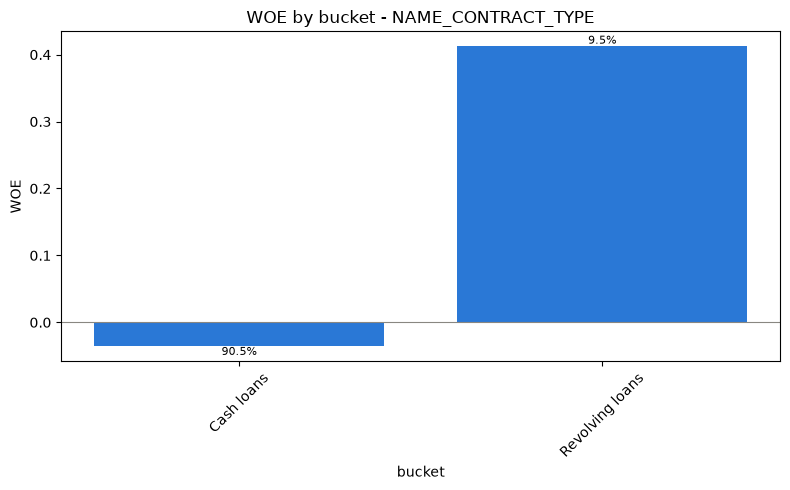

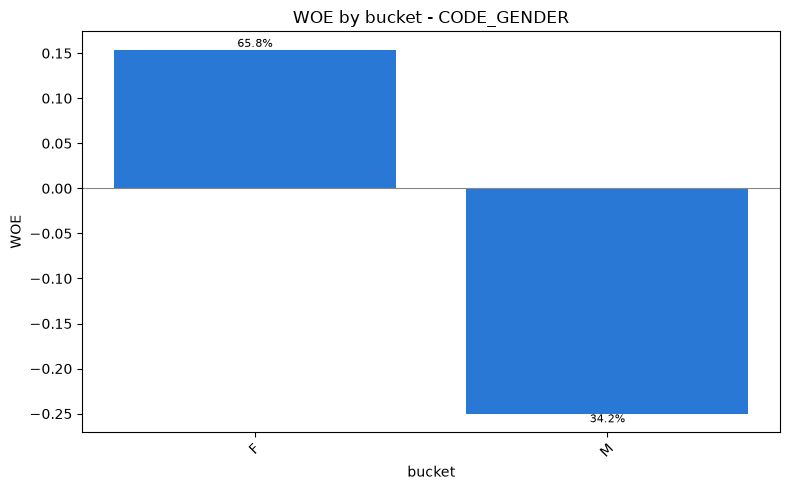

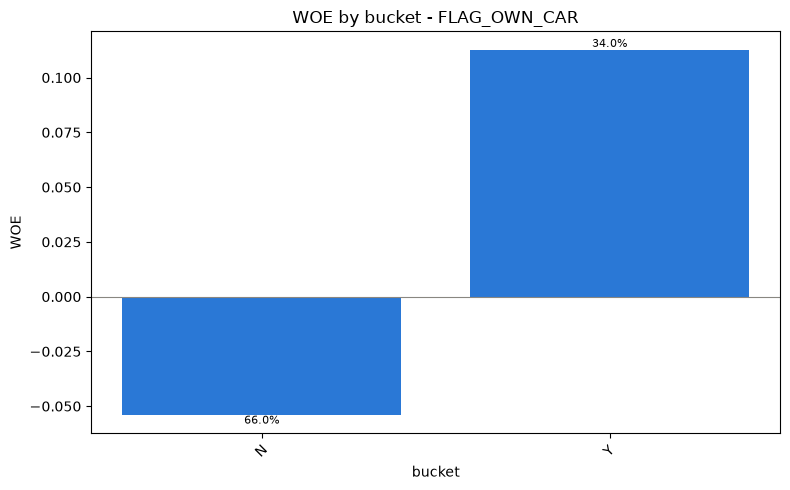

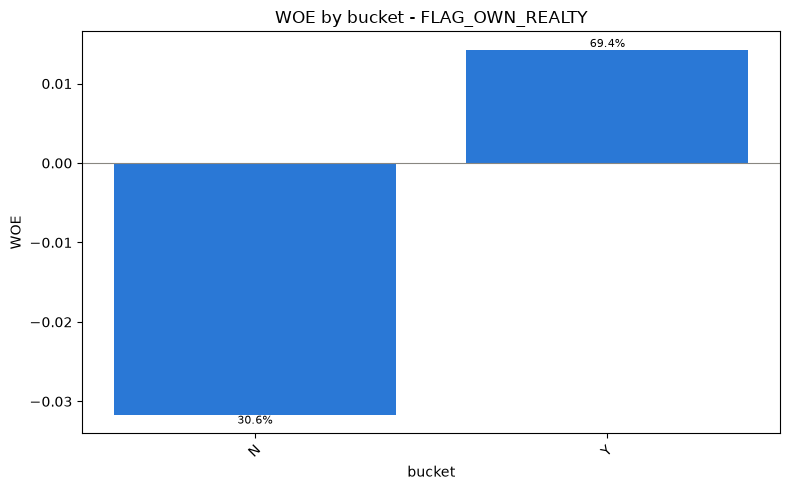

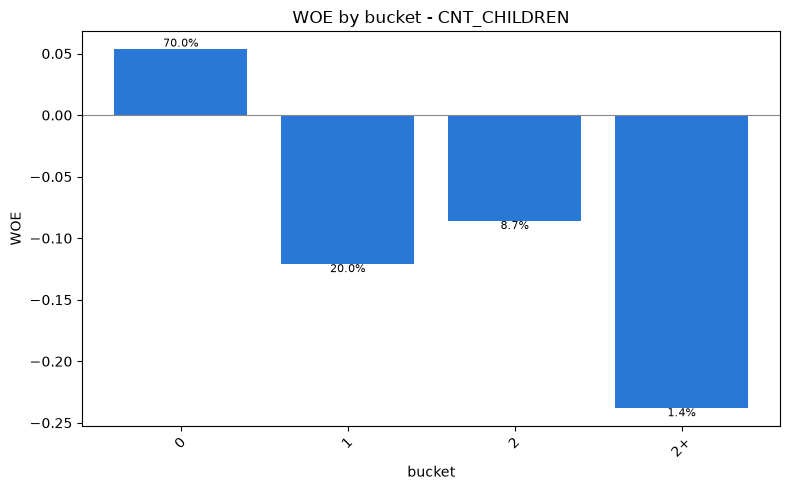

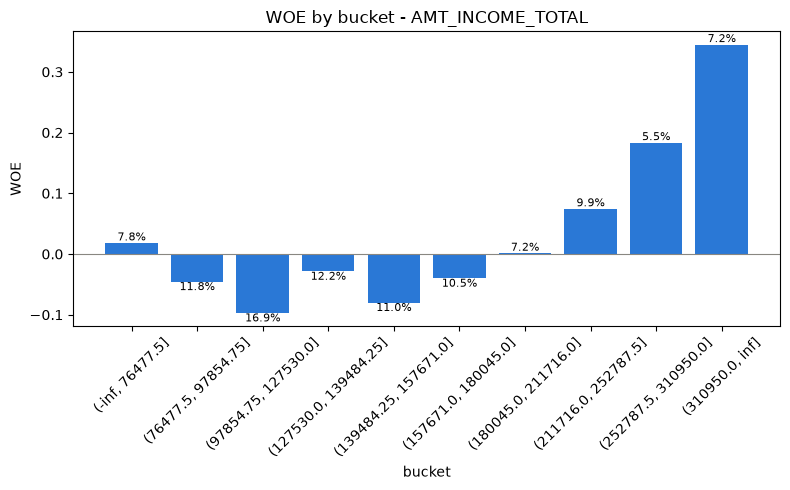

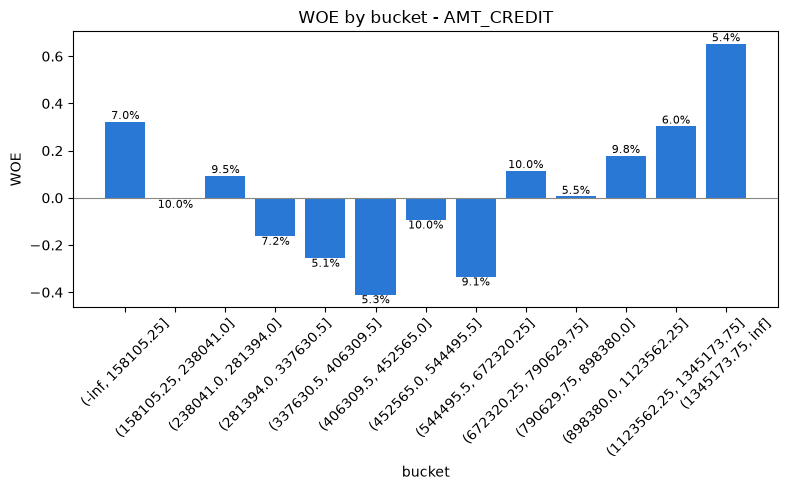

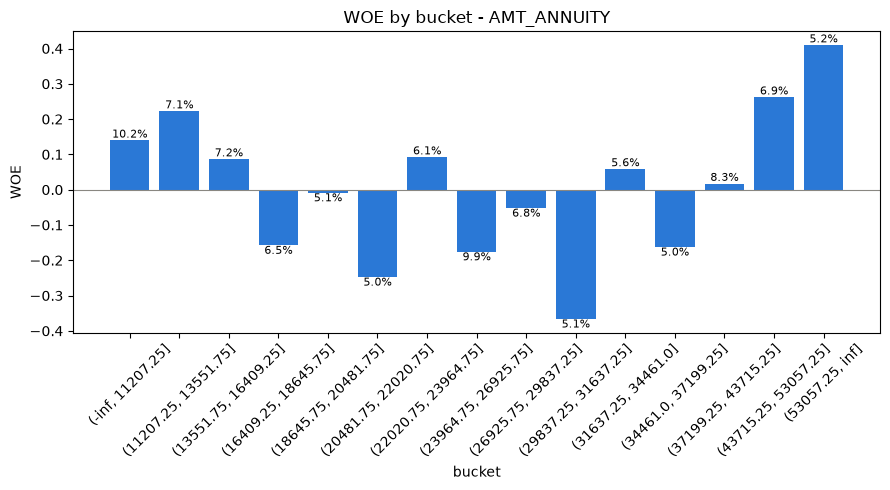

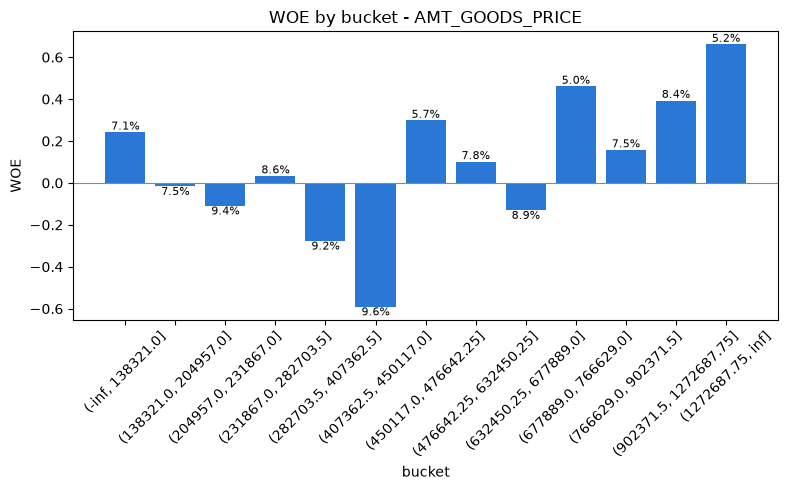

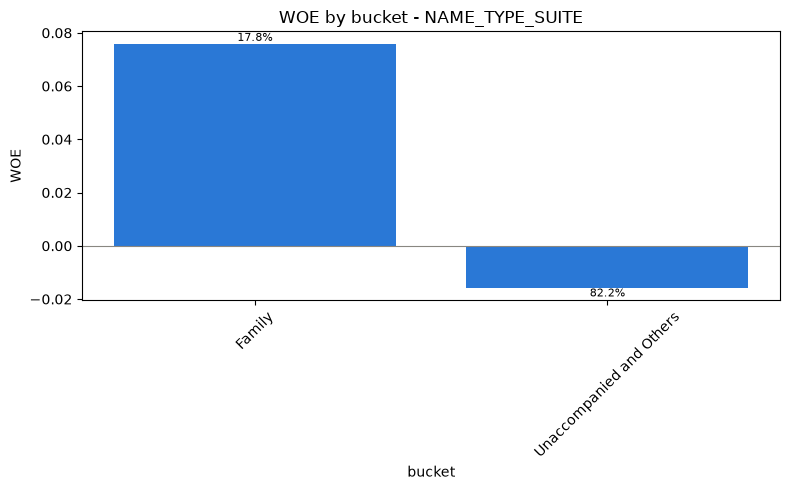

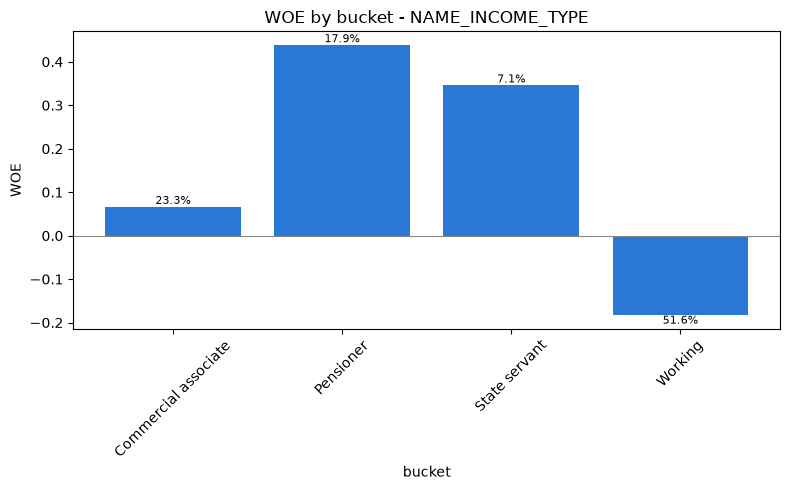

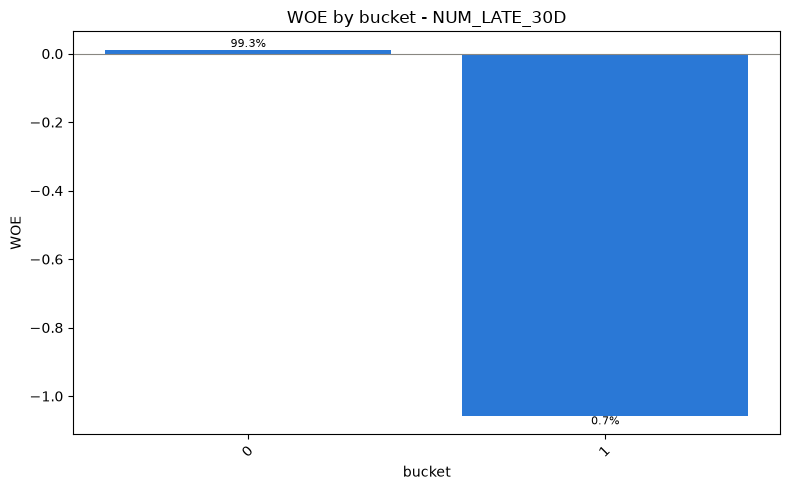

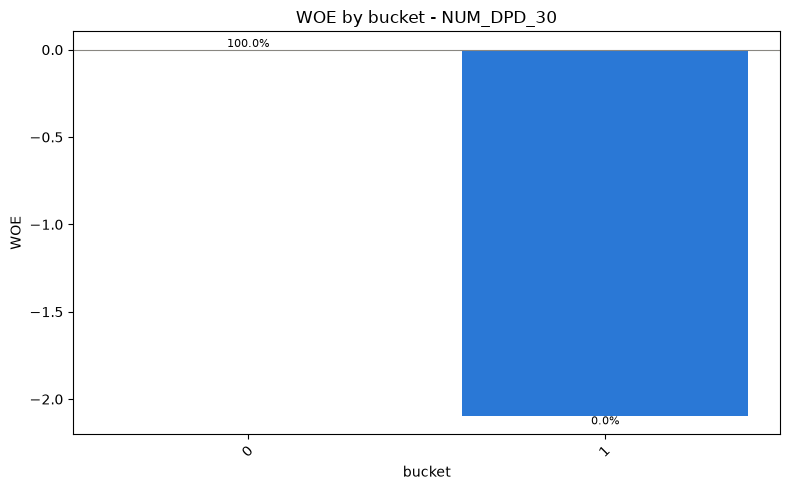

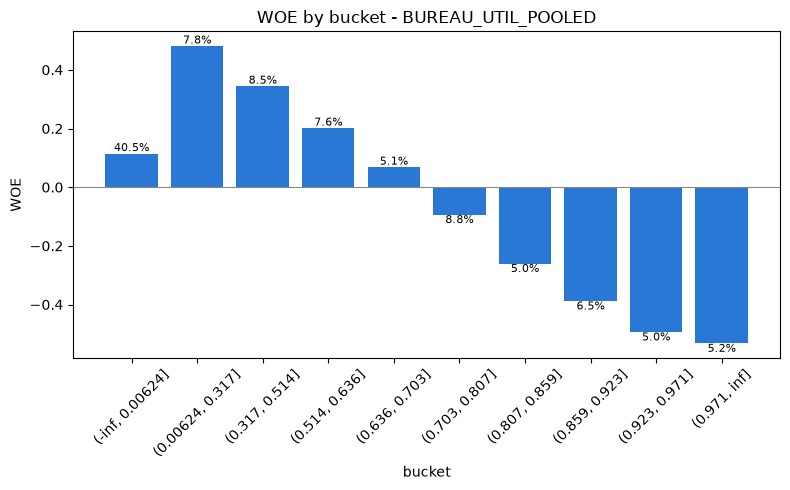

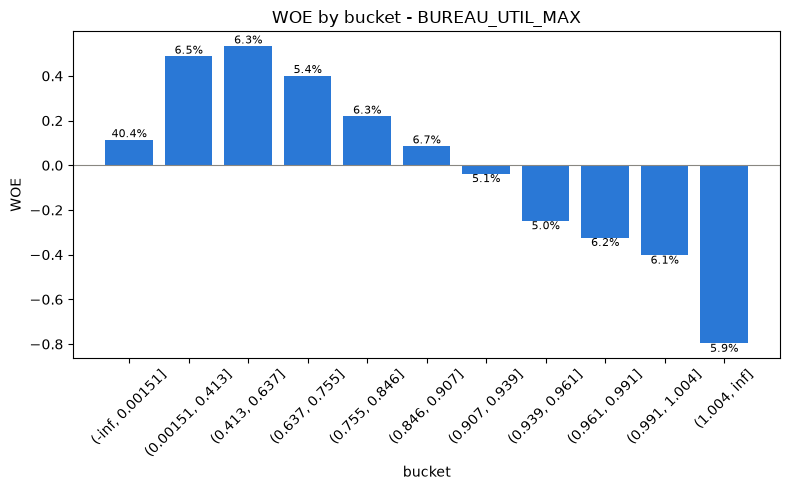

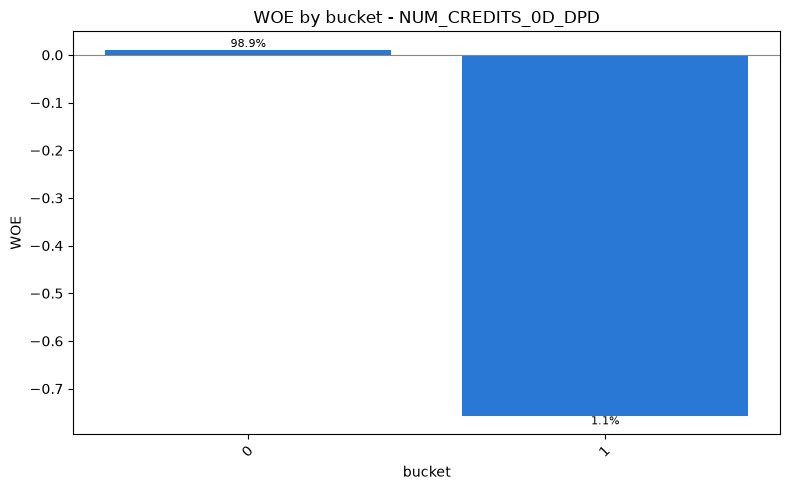

In [39]:
from palette import SEQUENTIAL_BLUE, INK_MUTED

for col in bureau_feature_cols:
    counts = bureau_X_train_grouped[col].value_counts(dropna=False)
    pct_of_data = 100 * counts / len(bureau_X_train_grouped)

    woe_table = pd.concat(
        [pct_of_data.rename("pct_of_data"), bureau_woe_maps[col].rename("woe")], axis=1,
    ).sort_index()

    fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(woe_table)), 5))
    bars = ax.bar(woe_table.index.astype(str), woe_table["woe"], color=SEQUENTIAL_BLUE)

    # Annotate each bar with its share of the training data, so a bucket's
    # WOE can be weighed against how common it actually is.
    for bar, pct in zip(bars, woe_table["pct_of_data"]):
        y = bar.get_height()
        va = "bottom" if y >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, y, f"{pct:.1f}%", ha="center", va=va, fontsize=8)

    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_title(f"WOE by bucket - {col}")
    ax.set_xlabel("bucket")
    ax.set_ylabel("WOE")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

In [40]:
bureau_logreg = LogisticRegression(max_iter=1000)
bureau_logreg.fit(bureau_X_train_woe, bureau_y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

## Evaluation

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     56538
           1       0.20      0.21      0.20      4965

    accuracy                           0.87     61503
   macro avg       0.56      0.57      0.57     61503
weighted avg       0.87      0.87      0.87     61503



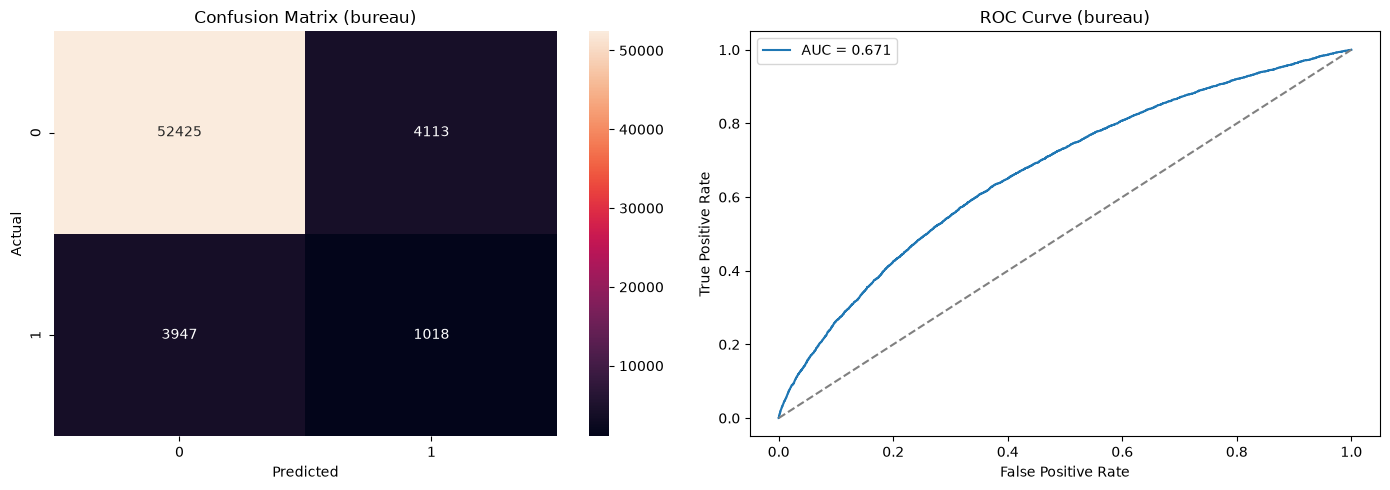

In [41]:
bureau_threshold = 0.15

bureau_positive_class_idx = list(bureau_logreg.classes_).index(1)
bureau_y_score = bureau_logreg.predict_proba(bureau_X_val_woe)[:, bureau_positive_class_idx]
bureau_y_pred = (bureau_y_score > bureau_threshold) * 1

print(classification_report(bureau_y_val, bureau_y_pred))

fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(bureau_y_val, bureau_y_pred), annot=True, fmt="d", ax=ax_cm)
ax_cm.set_title("Confusion Matrix (bureau)")
ax_cm.set_xlabel("Predicted")
ax_cm.set_ylabel("Actual")

bureau_fpr, bureau_tpr, _ = roc_curve(bureau_y_val, bureau_y_score)
bureau_auc = roc_auc_score(bureau_y_val, bureau_y_score)
ax_roc.plot(bureau_fpr, bureau_tpr, label=f"AUC = {bureau_auc:.3f}")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax_roc.set_title("ROC Curve (bureau)")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

plt.tight_layout()
plt.show()

## Coefficient to Score Conversion (Siddiqi)

Same `BASE_SCORE`/`BASE_ODDS`/`PDO` convention as the application-level
scorecard above - redefined locally in the cell below rather than reused,
since this section is treated as its own environment (no dependency on
cells above having already run).

In [ ]:
# Self-contained: BASE_SCORE/BASE_ODDS/PDO/FACTOR/OFFSET/build_scorecard()
# redefined here rather than relying on the application-level scorecard
# cell above having already run.
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)


def build_scorecard(woe_maps: dict, coefs: pd.Series, intercept: float, n_features: int, factor: float, offset: float) -> pd.DataFrame:
    """Per-bucket points table: one row per (feature, bucket) pair.

    points_i,b = -(beta_i * WOE_i,b + alpha / n_features) * factor
    """
    rows = []
    for feature, woe_map in woe_maps.items():
        beta = coefs[feature]
        for bucket, woe in woe_map.items():
            points = -(beta * woe + intercept / n_features) * factor
            rows.append({"feature": feature, "bucket": str(bucket), "woe": woe, "points": points})
    return pd.DataFrame(rows)


bureau_n_features = len(bureau_feature_cols)
bureau_intercept = bureau_logreg.intercept_[0]
bureau_coefs = pd.Series(bureau_logreg.coef_[0], index=bureau_feature_cols)

bureau_scorecard_table = build_scorecard(
    bureau_woe_maps, bureau_coefs, bureau_intercept, bureau_n_features, FACTOR, OFFSET,
)
bureau_scorecard_table.sort_values(["points"]).reset_index(drop=True)

## Analysis of the Scores of Engineered Features

In [ ]:
engineered_features = ["BUREAU_UTIL_POOLED", "BUREAU_UTIL_MAX", "NUM_LATE_30D", "NUM_DPD_30"]

for feature in engineered_features:
    print(bureau_scorecard_table[bureau_scorecard_table["feature"] == feature].to_string())
    print("\n")

               feature            bucket       woe    points
73  BUREAU_UTIL_POOLED   (-inf, 0.00624]  0.114052  5.849910
74  BUREAU_UTIL_POOLED  (0.00624, 0.317]  0.480653  9.616046
75  BUREAU_UTIL_POOLED    (0.317, 0.514]  0.343804  8.210178
76  BUREAU_UTIL_POOLED    (0.514, 0.636]  0.200770  6.740778
77  BUREAU_UTIL_POOLED    (0.636, 0.703]  0.067602  5.372730
78  BUREAU_UTIL_POOLED    (0.703, 0.807] -0.093664  3.716022
79  BUREAU_UTIL_POOLED    (0.807, 0.859] -0.260159  2.005602
80  BUREAU_UTIL_POOLED    (0.859, 0.923] -0.388018  0.692096
81  BUREAU_UTIL_POOLED    (0.923, 0.971] -0.493555 -0.392091
82  BUREAU_UTIL_POOLED      (0.971, inf] -0.532353 -0.790665


            feature            bucket       woe     points
83  BUREAU_UTIL_MAX   (-inf, 0.00151]  0.113892   7.277984
84  BUREAU_UTIL_MAX  (0.00151, 0.413]  0.487532  15.806800
85  BUREAU_UTIL_MAX    (0.413, 0.637]  0.533017  16.845042
86  BUREAU_UTIL_MAX    (0.637, 0.755]  0.400984  13.831224
87  BUREAU_UTIL_MAX    (0.755, 0

## Scoring a Row

Same `score_row()` logic as above, scoped to `bureau_scorecard_table` - sum a
row's per-bucket points, feature by feature, no separate offset addition
needed since the intercept's share is already folded into each bucket's
points.

In [ ]:
bureau_points_lookup = bureau_scorecard_table.set_index(["feature", "bucket"])["points"]


def bureau_score_row(row: pd.Series, feature_cols: list[str]) -> float:
    """Same "unseen bucket -> 0" fallback as score_row() above, scoped to
    bureau_points_lookup."""
    return sum(bureau_points_lookup.get((col, str(row[col])), 0.0) for col in feature_cols)


bureau_val_scores = bureau_val_bucketed[bureau_feature_cols].apply(
    lambda row: bureau_score_row(row, bureau_feature_cols), axis=1,
)
bureau_val_scores.describe()

count    61503.000000
mean        60.893800
std         17.051871
min         -3.364644
25%         49.639108
50%         61.452757
75%         72.646748
max        133.292030
dtype: float64

The conclusion to be obtained from today is that credit utilisation is quite an informative feature about a consumer's creditworthiness. Moving forward there will be more considerations of credit utilisation as a factor within all the datasets.